# PCA Image Compression

PCA is a lossy image codec. Keep only the top `k` principal components and each
784-pixel image is stored as just `k` numbers (its *code*); the decoder maps
those codes back to pixels. Small `k` -> tiny codes (big **compression ratio**)
but blurry reconstructions; large `k` -> near-perfect images but little saving.

This notebook studies that **quality-vs-size trade-off** on two datasets, using
the whole of each, with the helpers in
[`utils/pca/compression.py`](../utils/pca/compression.py):

- **Part 1 — MNIST** digits `0 / 1 / 2` ([`utils/mnist_data.py`](../utils/mnist_data.py))
- **Part 2 — Quick, Draw!** sketches `cat / apple / car` ([`utils/data_import.py`](../utils/data_import.py))

Both loaders return the same flat, `[0, 1]`-scaled `(n, 784)` matrix, so the
codec runs identically on either — only the loader changes.

In [1]:
import sys
from pathlib import Path

# Make src/ importable regardless of the launch cwd.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

from utils.mnist_data import load_digits, DIGITS, N_FEATURES
from utils.data_import import load_sketches, CLASSES
from utils.pca.dim_reduction import fit_pca, plot_eigenimages
from utils.pca.compression import (
    compression_sweep, plot_reconstruction_grid, plot_tradeoff, plot_normalized_comparison,
)

# Per-class sample cap. MNIST's classes are all smaller than this, so every
# training image is used; Quick, Draw!'s much larger categories are capped to it.
PER_CLASS = 10000
DIGITS, CLASSES, N_FEATURES

((0, 1, 2), ['cat', 'apple', 'car'], 784)

# Part 1 — MNIST digits (0 / 1 / 2)

## Load the data

MNIST's training split contains 5 923 `0`s, 6 742 `1`s and 5 958 `2`s. The
loader caps each class at `PER_CLASS = 10 000` samples; since every class holds
fewer than that, all **18 623** training images are used — a flat, `[0, 1]`-scaled
`(18623, 784)` matrix `X` and its integer label vector `y`.

In [2]:
X, y = load_digits(per_class=PER_CLASS)
print("X", X.shape, X.dtype, "range", (float(X.min()), float(X.max())))
print("classes", sorted(set(y.tolist())))

I0000 00:00:1784153546.465061   24819 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784153546.515243   24819 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784153547.820240   24819 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X (18623, 784) float32 range (0.0, 1.0)
classes [0, 1, 2]


## Reconstruct sample digits at several component counts

We fit one PCA per component count `k`, encode a handful of sample digits to
`k`-number codes, then decode them back to images. Reading top-to-bottom shows
detail returning as `k` grows.

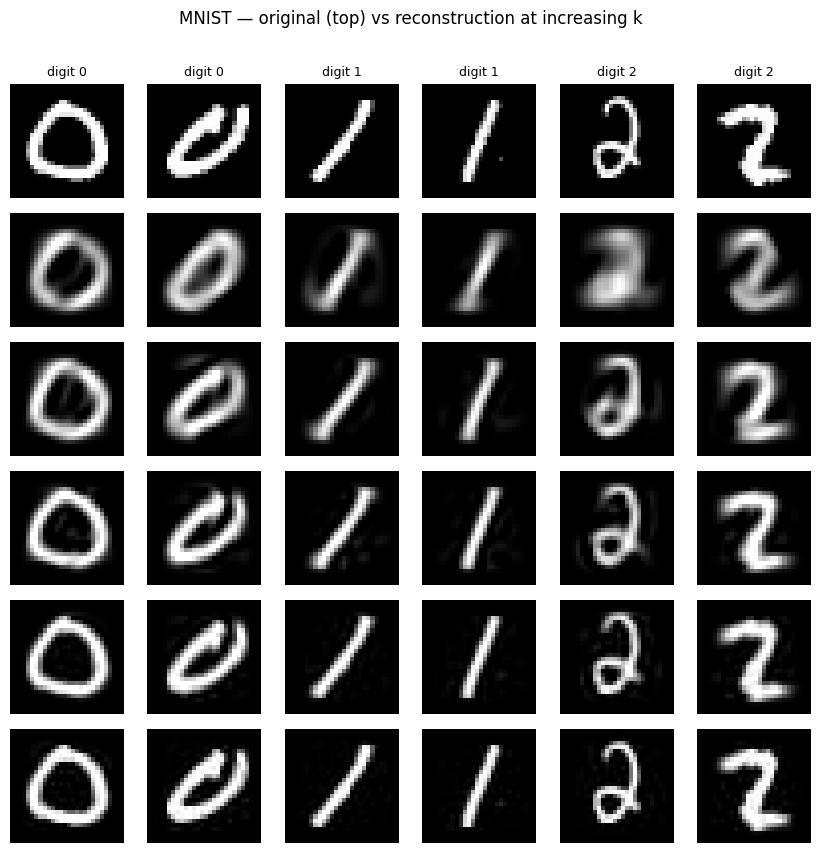

In [3]:
KS = [5, 20, 50, 100, 200]
plot_reconstruction_grid(X, y, [f"digit {d}" for d in DIGITS], KS,
                         suptitle="MNIST — original (top) vs reconstruction at increasing k")

At `k=5` the digits are barely legible smudges; by `k=50` they are clearly
readable, and `k=200` is visually almost indistinguishable from the originals.

## Quality vs. size across a sweep of k

For each `k` we fit PCA on the whole set, reconstruct every image, and record
the per-pixel reconstruction MSE and the compression ratio `784 / k`.

In [4]:
K_SWEEP = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400]
mses, ratios, var_mnist = compression_sweep(X, K_SWEEP)

total per-pixel variance = 0.06764
k=  1  ratio=784.00x  MSE=0.05272  normalized=0.779
k=  2  ratio=392.00x  MSE=0.04642  normalized=0.686
k=  5  ratio=156.80x  MSE=0.03488  normalized=0.516
k= 10  ratio= 78.40x  MSE=0.02551  normalized=0.377
k= 20  ratio= 39.20x  MSE=0.01691  normalized=0.250
k= 30  ratio= 26.13x  MSE=0.01238  normalized=0.183
k= 50  ratio= 15.68x  MSE=0.00778  normalized=0.115
k= 75  ratio= 10.45x  MSE=0.00508  normalized=0.075
k=100  ratio=  7.84x  MSE=0.00364  normalized=0.054
k=150  ratio=  5.23x  MSE=0.00213  normalized=0.031
k=200  ratio=  3.92x  MSE=0.00131  normalized=0.019
k=300  ratio=  2.61x  MSE=0.00047  normalized=0.007
k=400  ratio=  1.96x  MSE=0.00011  normalized=0.002


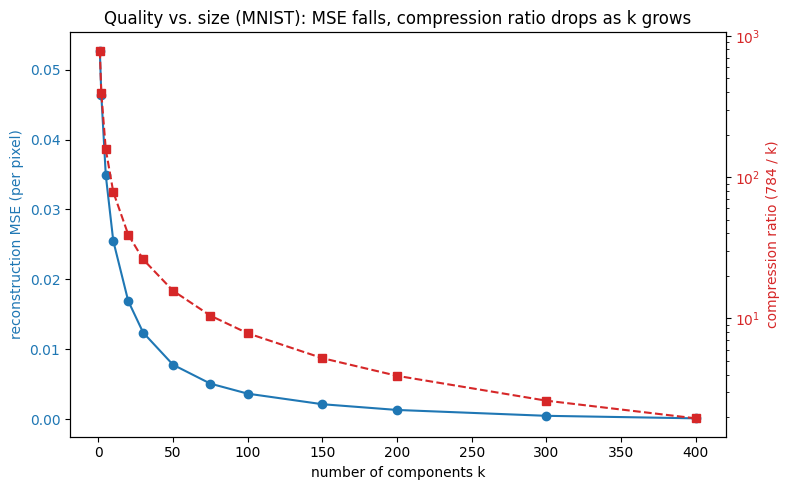

In [5]:
plot_tradeoff(K_SWEEP, mses, ratios,
              suptitle="Quality vs. size (MNIST): MSE falls, compression ratio drops as k grows")

### The basis the codec compresses onto

Compression is not magic: each image's `k`-number code is just its coordinates on
the top `k` principal components. Those components are the codec's **basis
images** — reshaping them to 28×28 shows the building blocks every reconstruction
is assembled from (mean image + a weighted sum of these).

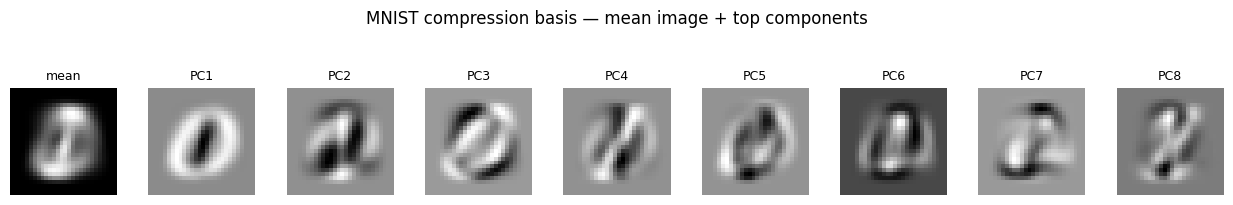

In [6]:
plot_eigenimages(fit_pca(X), n=8, suptitle="MNIST compression basis — mean image + top components")

### Does the centering choice matter for compression?

The dimensionality-reduction notebook showed that **global** centering wastes PC1
on the mean image. Compression makes the cost concrete: with one component spent
re-drawing the average digit, fewer are left to reconstruct detail, so at every
`k` the reconstruction is slightly worse. We rerun the sweep with global centering
and overlay the normalized error.

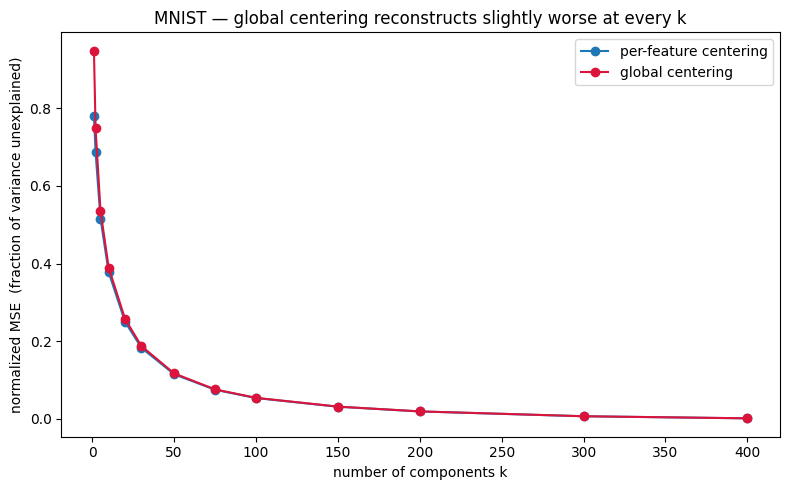

In [7]:
# `mses` above used the default per-feature centering; rerun with global centering.
mses_glob, _, var_glob = compression_sweep(X, K_SWEEP, center="global", verbose=False)

plot_normalized_comparison(
    K_SWEEP,
    [("per-feature centering", mses, var_mnist, "tab:blue"),
     ("global centering", mses_glob, var_glob, "crimson")],
    suptitle="MNIST — global centering reconstructs slightly worse at every k",
)

The global-centering curve sits just **above** the per-feature one at every `k`:
the same code size buys a slightly worse reconstruction, because one of the `k`
components is busy re-drawing the mean image instead of adding detail. The gap is
modest (a component's worth) but consistent — confirming, from the compression
side, that per-feature centering is the better default.

## Interpretation & a "good enough" k

The two curves move in opposite directions:

- **Reconstruction MSE** falls steeply for the first ~50 components, then
  flattens into diminishing returns — the leading components capture the bulk of
  the digit structure (strokes, orientation), later ones only fine texture.
- **Compression ratio** is `784 / k`, so it plummets as we add components: going
  from `k=50` (≈16x smaller) to `k=200` (≈4x smaller) quadruples storage for only
  a small MSE improvement.

**Sweet spot: k ≈ 50.** It sits at the elbow of the MSE curve — reconstructions
are clearly legible (see the image grid) — while still giving roughly a **16x**
reduction in stored numbers per image. If quality matters more than size,
`k ≈ 100` (≈8x, visually crisp) is a reasonable step up; below `k ≈ 20` the
savings are large but digits start to blur together.

# Part 2 — Quick, Draw! sketches (cat / apple / car)

The **same codec** is applied to hand-drawn sketches. `load_sketches` yields the
identical `(n, 784)`, `[0, 1]` contract, so `compression_sweep` and the plotting
helpers are reused unchanged. Each category holds over 100 000 drawings; the
loader caps each at `PER_CLASS = 10 000`, for a balanced **30 000**-sketch matrix.

The dimensionality-reduction notebook showed sketches are far *less* compressible
than digits (their variance is spread across many more components), so at a given
`k` a smaller *fraction* of their variance is captured and reconstructions look
blurrier.

One caveat, handled below: raw per-pixel MSE is **not** comparable across the two
datasets — sketches are mostly empty background, so their absolute error is small
no matter how well the shapes compress. The comparison therefore uses a
**normalized** MSE instead.

X (30000, 784) float32 range (0.0, 1.0)
classes [0, 1, 2] -> ['cat', 'apple', 'car']


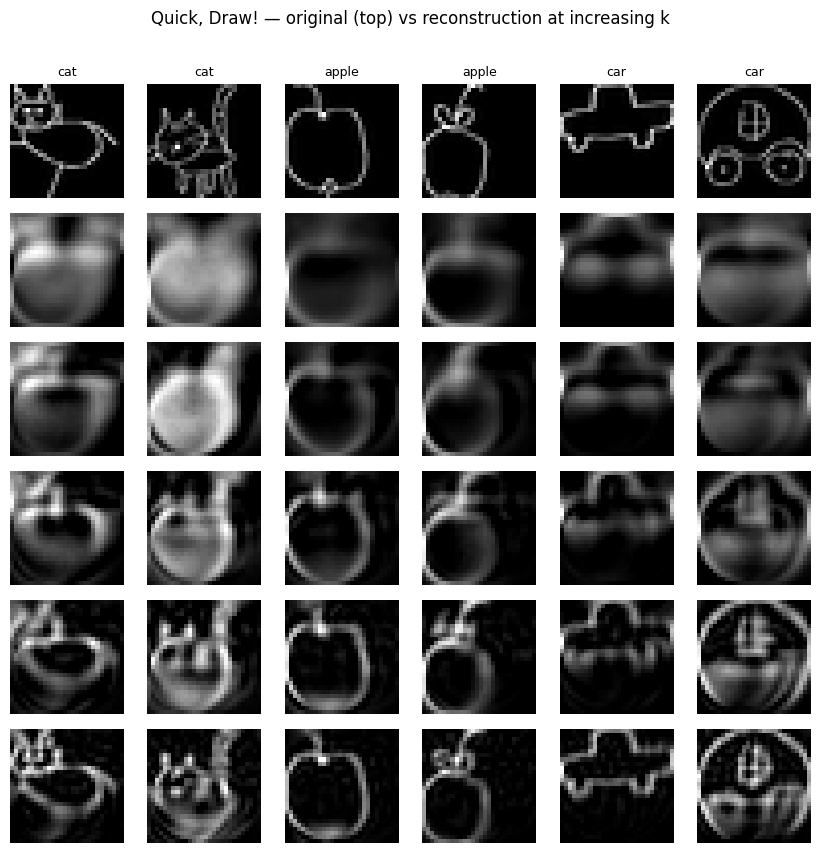

In [8]:
X, y = load_sketches(per_class=PER_CLASS)
print("X", X.shape, X.dtype, "range", (float(X.min()), float(X.max())))
print("classes", sorted(set(y.tolist())), "->", CLASSES)

plot_reconstruction_grid(X, y, CLASSES, KS,
                         suptitle="Quick, Draw! — original (top) vs reconstruction at increasing k")

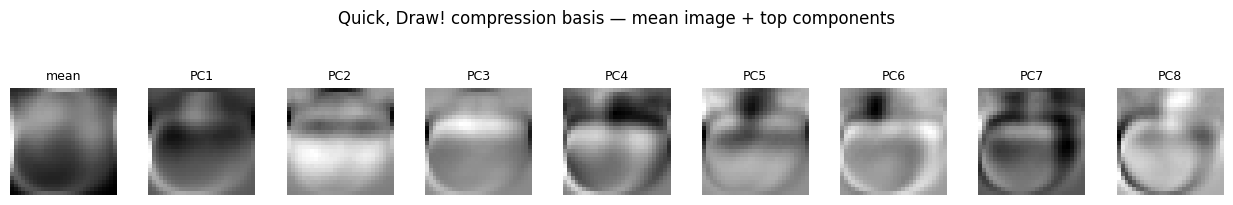

In [9]:
# The sketch codec's basis (compare with MNIST's crisp stroke patterns above).
plot_eigenimages(fit_pca(X), n=8, suptitle="Quick, Draw! compression basis — mean image + top components")

In [10]:
mses_qd, ratios_qd, var_qd = compression_sweep(X, K_SWEEP)
print(f"\n(for comparison, MNIST total per-pixel variance was {var_mnist:.5f})")

total per-pixel variance = 0.00458
k=  1  ratio=784.00x  MSE=0.00432  normalized=0.943
k=  2  ratio=392.00x  MSE=0.00416  normalized=0.909
k=  5  ratio=156.80x  MSE=0.00384  normalized=0.839
k= 10  ratio= 78.40x  MSE=0.00354  normalized=0.773
k= 20  ratio= 39.20x  MSE=0.00316  normalized=0.690
k= 30  ratio= 26.13x  MSE=0.00290  normalized=0.633
k= 50  ratio= 15.68x  MSE=0.00250  normalized=0.547
k= 75  ratio= 10.45x  MSE=0.00214  normalized=0.468
k=100  ratio=  7.84x  MSE=0.00185  normalized=0.405
k=150  ratio=  5.23x  MSE=0.00142  normalized=0.310
k=200  ratio=  3.92x  MSE=0.00111  normalized=0.241
k=300  ratio=  2.61x  MSE=0.00067  normalized=0.147
k=400  ratio=  1.96x  MSE=0.00040  normalized=0.087

(for comparison, MNIST total per-pixel variance was 0.06764)


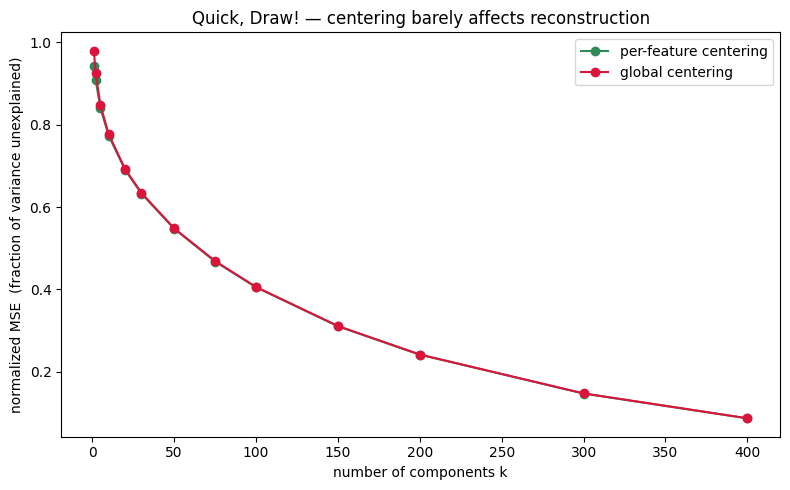

In [11]:
# Two-means check on sketches. Because global centering barely disturbs the
# sparse sketch mean image, the two curves nearly coincide (unlike MNIST).
mses_qd_glob, _, var_qd_glob = compression_sweep(X, K_SWEEP, center="global", verbose=False)

plot_normalized_comparison(
    K_SWEEP,
    [("per-feature centering", mses_qd, var_qd, "seagreen"),
     ("global centering", mses_qd_glob, var_qd_glob, "crimson")],
    suptitle="Quick, Draw! — centering barely affects reconstruction",
)

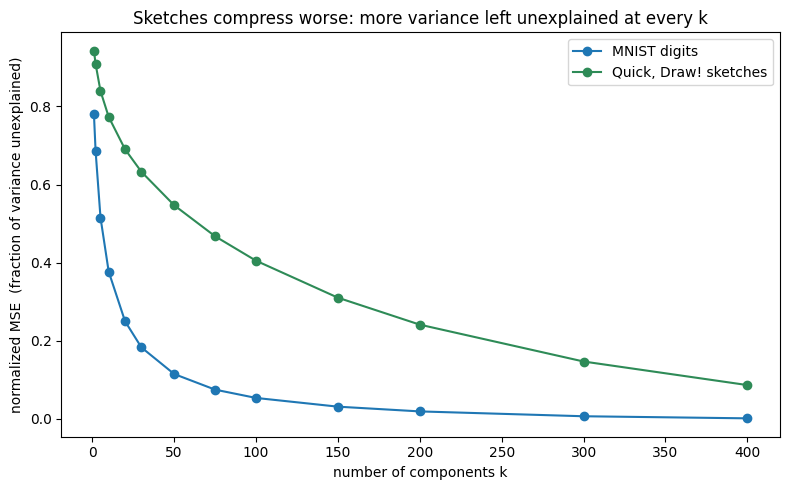

In [12]:
# Fair cross-dataset comparison: normalized MSE = MSE / total pixel variance,
# i.e. the fraction of each dataset's variance still unexplained at k components.
# (Raw MSE isn't comparable -- sketches are mostly empty background, so their
# absolute per-pixel error is small regardless of how well the shapes compress.)
plot_normalized_comparison(
    K_SWEEP,
    [("MNIST digits", mses, var_mnist, "tab:blue"),
     ("Quick, Draw! sketches", mses_qd, var_qd, "seagreen")],
    suptitle="Sketches compress worse: more variance left unexplained at every k",
)

## MNIST vs. Quick, Draw! — compression takeaway

- **Raw MSE is misleading here.** In absolute per-pixel MSE the sketches actually score *lower* than the digits at every `k` — but only because a sketch is mostly blank background (its total pixel variance is much smaller, printed above), so there is simply less error to make. That says nothing about how well the *shapes* compress.
- **Normalized, sketches compress worse.** Dividing by each dataset's own variance (the fraction of variance left unexplained) puts them on the same scale, and the sketch curve sits **above** the digit curve at every `k`: the same code size captures a smaller share of a sketch's structure. This is the compression-side echo of the dimensionality-reduction result (403 vs 68 components for 90% variance).
- **Same codec, different data.** The `k ≈ 50` sweet spot that gave crisp, legible digits leaves sketches visibly blurrier; matching digit quality would take a larger `k` (smaller compression ratio). The code never changed — only how compressible the underlying data is.